# Econometric Analysis of EV/EBITDA Determinants

This notebook estimates and diagnoses cross-sectional valuation models for EV/EBITDA.

Interpretation workflow used throughout:
1. Validate data structure and variable distributions.
2. Analyze dependence structure (Spearman and Pearson correlations).
3. Estimate baseline OLS specification.
4. Test theoretically motivated non-linear blocks (quadratic leverage and liquidity effects).
5. Compare sensitivity across alternative samples and specifications.
6. Diagnose heteroskedasticity, misspecification, multicollinearity, and structural instability.
7. Re-estimate with robust/FGLS-style corrections and assess whether economic conclusions remain stable.

Main interpretation principle: statistical significance is treated jointly with economic sign, magnitude, and robustness across model variants.

In [50]:
from pathlib import Path
import pandas as pd

In [51]:
raw_path = Path("../data/processed/df_cleaned.csv")
df = pd.read_csv(raw_path)
df.head()

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,INTC,Technology,7.0919,0.1289,0.297,0.617336,0.2824,1.446586,0.553660,0.3535,0.2143,0.1912,0.0256,1.731
1,MU,Technology,3.0421,0.4955,0.465,0.588694,0.4377,1.283837,0.700641,0.1436,0.2922,0.0704,0.0000,2.787
2,AAPL,Technology,13.6724,0.1586,0.224,0.383437,0.5556,6.430249,0.726215,1.0685,0.0501,0.0536,0.0120,1.133
3,MSFT,Technology,15.3298,0.1428,0.150,0.652474,0.2003,3.053173,0.426351,0.9890,0.1054,0.1334,0.0165,2.901
4,F,Consumer Cyclical,10.8702,0.0227,0.023,0.091095,0.1023,4.431920,0.625002,4.2918,0.0486,0.0000,0.0784,1.200


In [52]:
df.describe()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
count,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000
mean,12.326177,0.117927,0.090638,0.418011,0.137103,7.987580,0.904659,0.811507,0.068813,0.019866,0.015796,2.288411
std,7.601877,0.131578,0.192334,0.226630,0.142767,8.524205,0.541097,0.841738,0.124773,0.041190,0.020835,1.331703
min,0.879500,-0.132500,-0.561000,0.032281,-0.489300,0.050494,0.041906,0.000000,-1.434300,0.000000,0.000000,0.810000
25%,7.331725,0.036600,0.029000,0.250585,0.054700,2.319930,0.486263,0.206275,0.018800,0.000000,0.000000,1.373570
50%,10.613250,0.088450,0.064000,0.369266,0.114600,5.397089,0.797437,0.581650,0.034800,0.000000,0.009300,1.896500
75%,15.087225,0.169825,0.117000,0.549022,0.194725,10.171398,1.255165,1.092525,0.068950,0.014150,0.024750,2.764000
max,47.722600,0.762800,5.652000,1.000000,0.822600,43.335593,2.455339,4.438900,0.737600,0.191200,0.112200,7.870000


In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

In [54]:
df = df.rename(columns={'R&D_to_Revenue': 'R_and_D_to_Revenue'})

In [55]:
df.loc[:, 'Debt_to_Equity_squared'] = df['Debt_to_Equity'] ** 2
df.loc[:, 'currentRatio_squared'] = df['currentRatio'] ** 2

## Why Quadratic Terms Are Included

Two variables are expanded with squared terms: Debt_to_Equity_squared and currentRatio_squared.

Economic reason for Debt_to_Equity_squared: the leverage-valuation relation is typically non-linear. Moderate leverage can support value (tax shield, capital discipline), but excessive leverage increases expected distress and refinancing risk. Including both Debt_to_Equity and Debt_to_Equity_squared allows the model to estimate this curved effect instead of forcing a purely linear slope.

Economic reason for currentRatio_squared: liquidity also tends to have an interior optimum. Very low liquidity increases short-term risk, while excessively high liquidity can indicate inefficient working-capital or cash allocation. A quadratic term captures the idea that both extremes may be penalized by the market.

Modeling implication: if linear and squared coefficients are jointly significant, the data support a non-monotonic valuation channel.

In [56]:
df = df.dropna()

In [57]:
model_columns = ['Enterprise_Value_over_EBITDA',
                    'Revenue_Growth',
                    'Profit_Margin', 'grossProfitMargin', 
                    'returnOnEquity',
                    'fixedAssetTurnover', 'assetTurnover', 'Debt_to_Equity',
                    'Debt_to_Equity_squared',
                    'Capex_to_Revenue', 'R_and_D_to_Revenue', 
                    'Dividend_Yield', 'currentRatio_squared', 'currentRatio', 'Sector'
                    ]

In [58]:
df = df[model_columns]

In [59]:
heatmap_columns = ['Enterprise_Value_over_EBITDA',
                    'Revenue_Growth',
                    'grossProfitMargin', 
                    'returnOnEquity',
                    'assetTurnover', 'Debt_to_Equity',
                    'Debt_to_Equity_squared',
                    'Capex_to_Revenue', 'R_and_D_to_Revenue', 
                    'Dividend_Yield', 'currentRatio_squared', 'currentRatio',
                    ]

In [60]:
df_heatmap = df[heatmap_columns]

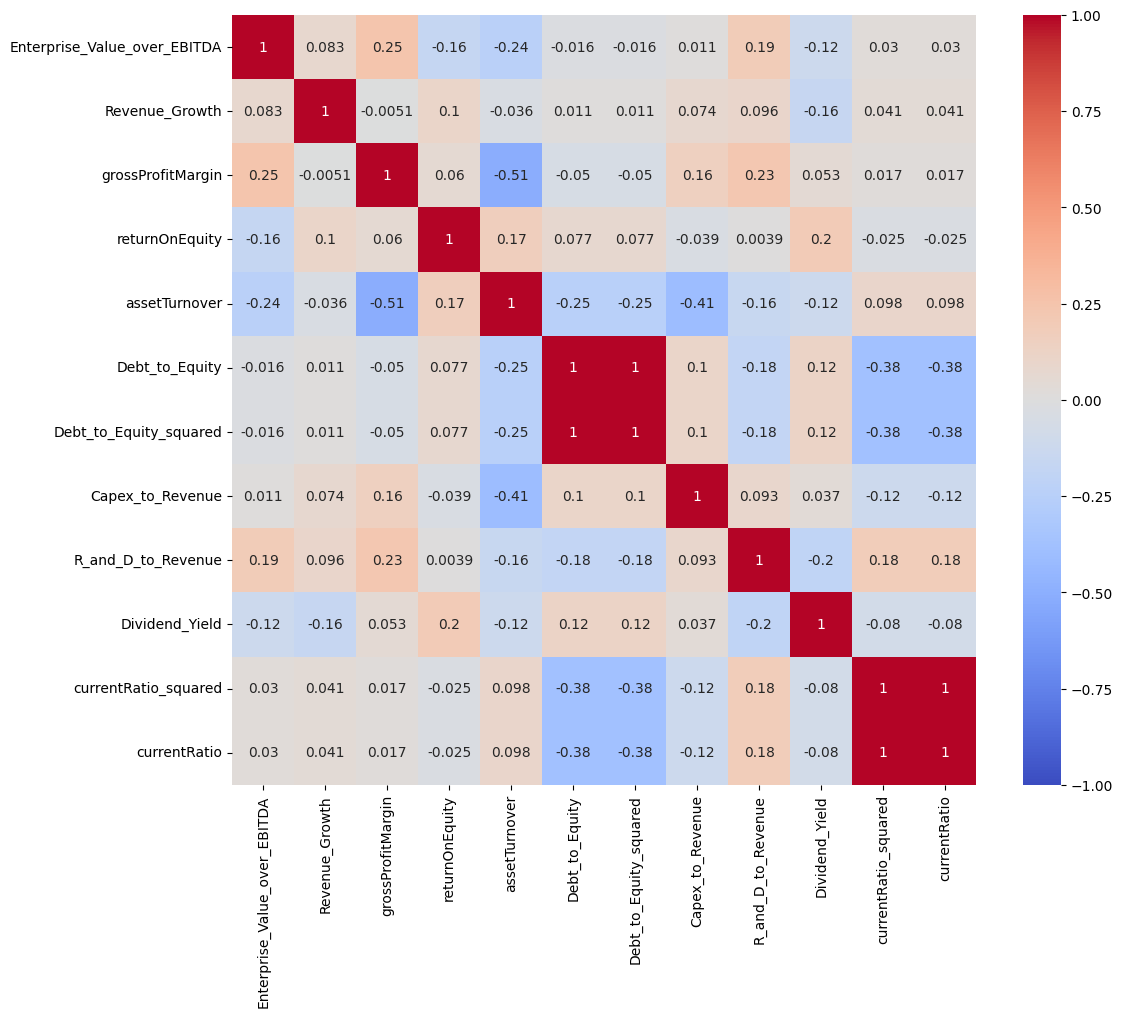

In [61]:
plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(df_heatmap.corr(method='spearman'), 
                      vmin=-1, vmax=1, 
                      annot=True, cmap='coolwarm')



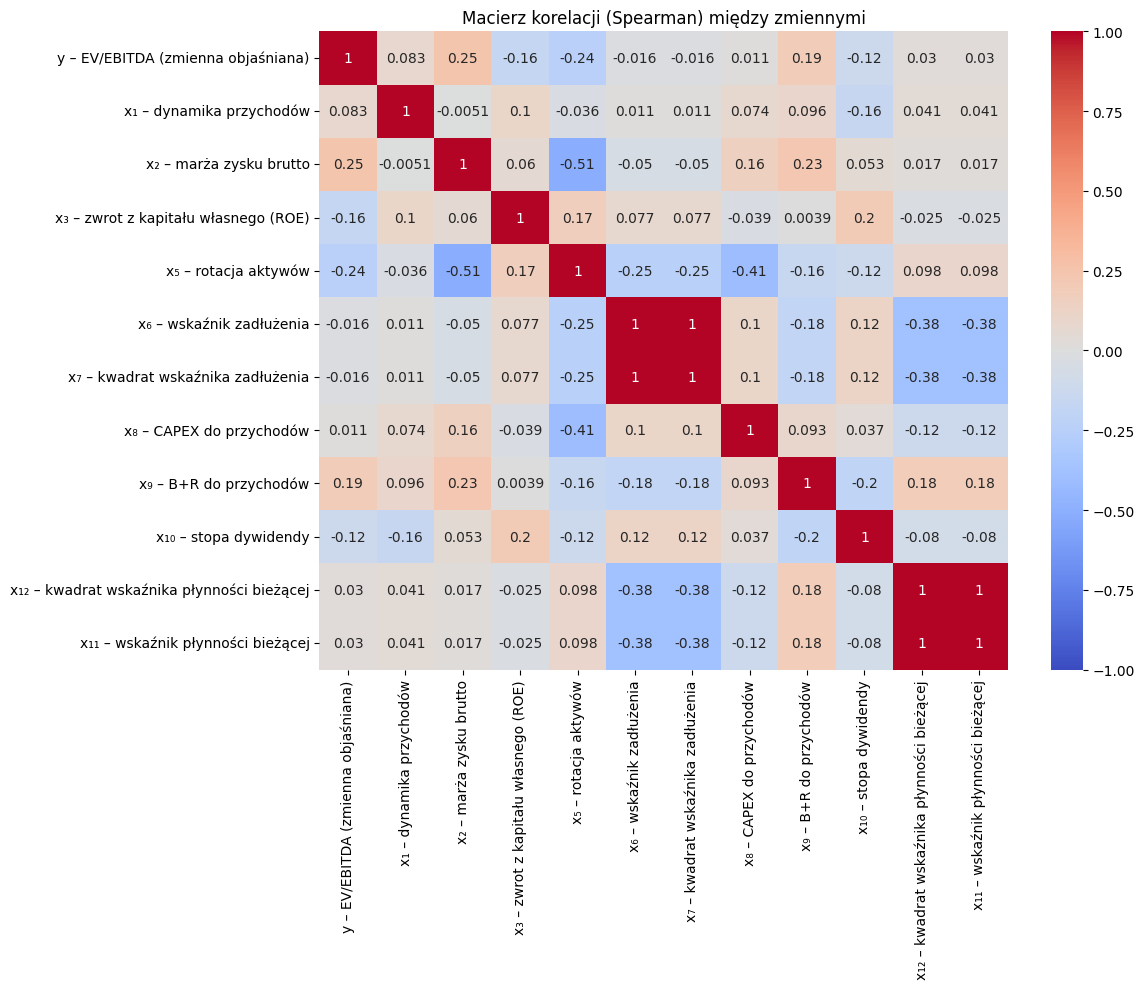

In [ ]:
column_name_map = {
    'Revenue_Growth': 'x1 - Revenue growth',
    'grossProfitMargin': 'x2 - Gross profit margin',
    'returnOnEquity': 'x3 - Return on equity (ROE)',
    'assetTurnover': 'x5 - Asset turnover',
    'Debt_to_Equity': 'x6 - Debt-to-equity ratio',
    'Debt_to_Equity_squared': 'x7 - Debt-to-equity ratio squared',
    'Capex_to_Revenue': 'x8 - CAPEX to revenue',
    'R_and_D_to_Revenue': 'x9 - R&D to revenue',
    'Dividend_Yield': 'x10 - Dividend yield',
    'currentRatio': 'x11 - Current ratio',
    'currentRatio_squared': 'x12 - Current ratio squared',
    'Enterprise_Value_over_EBITDA': 'y - EV/EBITDA (dependent variable)'
}

df_renamed = df_heatmap.rename(columns=column_name_map).rename(index=column_name_map)

plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(df_renamed.corr(method='spearman'),
                      vmin=-1, vmax=1,
                      annot=True, cmap='coolwarm')
plt.title('Spearman Correlation Matrix Between Variables')
plt.tight_layout()
plt.show()

## Correlation Block: Practical Takeaway

Purpose: quickly check whether dependence patterns indicate identification risk before estimation.

Result and meaning: the correlation matrices are treated as a specification-risk filter (especially for variable and squared-variable pairs), not as a rule for dropping economically relevant regressors. Final specification decisions are made only after stability tests and residual diagnostics.

In [63]:
df_heatmap.corr(method = 'pearson')

,Enterprise_Value_over_EBITDA,Revenue_Growth,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,Dividend_Yield,currentRatio_squared,currentRatio
Enterprise_Value_over_EBITDA,1.000000,0.121065,0.204463,-0.171253,-0.212398,-0.050837,-0.028171,-0.008111,0.289885,-0.161401,0.047115,0.050223
Revenue_Growth,0.121065,1.000000,0.016400,0.025491,-0.060825,0.021814,0.029628,0.114368,0.069450,-0.153380,0.005360,0.012628
grossProfitMargin,0.204463,0.016400,1.000000,0.077310,-0.476235,-0.002795,0.010985,0.156560,0.247110,0.125350,0.047894,0.030845
returnOnEquity,-0.171253,0.025491,0.077310,1.000000,0.111713,0.204154,0.211621,-0.064442,0.037221,0.094255,-0.018830,-0.019626
assetTurnover,-0.212398,-0.060825,-0.476235,0.111713,1.000000,-0.186344,-0.128724,-0.318633,-0.184585,-0.139864,-0.025483,0.002578
Debt_to_Equity,-0.050837,0.021814,-0.002795,0.204154,-0.186344,1.000000,0.923718,0.062848,-0.158557,0.143591,-0.223232,-0.274549
Debt_to_Equity_squared,-0.028171,0.029628,0.010985,0.211621,-0.128724,0.923718,1.000000,0.044078,-0.109420,0.112462,-0.125590,-0.169480
Capex_to_Revenue,-0.008111,0.114368,0.156560,-0.064442,-0.318633,0.062848,0.044078,1.000000,-0.023713,0.009461,-0.060788,-0.090597
R_and_D_to_Revenue,0.289885,0.069450,0.247110,0.037221,-0.184585,-0.158557,-0.109420,-0.023713,1.000000,-0.180969,0.179283,0.194569
Dividend_Yield,-0.161401,-0.153380,0.125350,0.094255,-0.139864,0.143591,0.112462,0.009461,-0.180969,1.000000,-0.032258,-0.052088


In [64]:
df["positiveROE"] = (df["returnOnEquity"] > 0).astype(int)
df["returnOnEquityXpositiveROE"] = df["returnOnEquity"] * df["positiveROE"]

In [65]:
import statsmodels.formula.api as smf

In [66]:
formula = """
Enterprise_Value_over_EBITDA ~ 
    Revenue_Growth+ grossProfitMargin + returnOnEquity + assetTurnover + Debt_to_Equity + Debt_to_Equity_squared + 
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + 
    currentRatio + currentRatio_squared + returnOnEquityXpositiveROE
"""

In [67]:
model_lin_lin = smf.ols(formula=formula, data=df).fit()

In [68]:
print(model_lin_lin.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.188
Model:                                      OLS   Adj. R-squared:                  0.181
Method:                           Least Squares   F-statistic:                     24.43
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):           1.18e-49
Time:                                  00:30:44   Log-Likelihood:                -4265.1
No. Observations:                          1276   AIC:                             8556.
Df Residuals:                              1263   BIC:                             8623.
Df Model:                                    12                                         
Covariance Type:                      nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

## Baseline OLS: Key Result and Meaning

Purpose: provide the benchmark specification for the full pipeline and for subsequent restriction and robustness tests.

Result: the baseline model reaches $R^2 = 0.188$ (adj. $R^2 = 0.181$), with a highly significant global test ($\mathrm{Prob}(F)=1.18\times 10^{-49}$).

Meaning: the model explains about 18.8% of cross-sectional EV/EBITDA variation, so the economic signal is meaningful, while a substantial share of dispersion still reflects omitted drivers (for example firm-specific factors, market sentiment, and sector-specific effects).

In [69]:
hypotheses = """
Debt_to_Equity = 0,
Debt_to_Equity_squared = 0
"""

In [70]:
f_test_result = model_lin_lin.f_test(hypotheses)
print(f_test_result)

<F test: F=1.5516117947579249, p=0.21230980297035043, df_denom=1.26e+03, df_num=2>


In [71]:
hypotheses2 = """
currentRatio = 0,
currentRatio_squared = 0
"""

In [72]:
f_test_result = model_lin_lin.f_test(hypotheses2)
print(f_test_result)

<F test: F=0.17973821391454903, p=0.8355102690450933, df_denom=1.26e+03, df_num=2>


## Non-Linear Blocks: Test Outcome and Decision

Purpose: test whether quadratic leverage and liquidity channels are needed already in the baseline model.

Result:
- Debt_to_Equity + Debt_to_Equity_squared block: $p=0.2123$ (no basis to reject the restriction),
- currentRatio + currentRatio_squared block: $p=0.8355$ (no basis to reject the restriction).

Meaning: in the baseline specification, non-linearity is not yet statistically strong; therefore, retaining squared terms relies on economic theory and later validation in richer specifications (especially sector-augmented and weighted models).

In [73]:
raw_path = Path("../data/processed/df_minimally_cleaned.csv")
df_minimally_cleaned = pd.read_csv(raw_path)
df_minimally_cleaned.head()

,Company_symbol,Sector,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Capex_to_Revenue,R&D_to_Revenue,Dividend_Yield,currentRatio
0,CMCSA,Consumer Cyclical,8.9618,0.1115,0.124,1.000000,0.1638,2.126764,0.375499,1.5604,0.1303,0.0000,0.0269,0.792
1,KMI,Energy,10.6065,0.0320,0.105,0.484729,0.0478,0.373222,0.179342,1.1083,0.2067,0.0000,0.0471,0.757
2,INTC,Technology,7.0919,0.1289,0.297,0.617336,0.2824,1.446586,0.553660,0.3535,0.2143,0.1912,0.0256,1.731
3,MU,Technology,3.0421,0.4955,0.465,0.588694,0.4377,1.283837,0.700641,0.1436,0.2922,0.0704,0.0000,2.787
4,AAPL,Technology,13.6724,0.1586,0.224,0.383437,0.5556,6.430249,0.726215,1.0685,0.0501,0.0536,0.0120,1.133


In [74]:
df_minimally_cleaned.loc[:, 'Debt_to_Equity_squared'] = df_minimally_cleaned['Debt_to_Equity'] ** 2
df_minimally_cleaned.loc[:, 'currentRatio_squared'] = df_minimally_cleaned['currentRatio'] ** 2
df_minimally_cleaned["positiveROE"] = (df_minimally_cleaned["returnOnEquity"] > 0).astype(int)
df_minimally_cleaned["returnOnEquityXpositiveROE"] = df_minimally_cleaned["returnOnEquity"] * df_minimally_cleaned["positiveROE"]

In [ ]:
df_minimally_cleaned = df_minimally_cleaned.rename(columns={'R&D_to_Revenue': 'R_and_D_to_Revenue'})
model_with_outliers = smf.ols(formula="""
Enterprise_Value_over_EBITDA ~ 
    Revenue_Growth + Profit_Margin + grossProfitMargin + returnOnEquity + 
    fixedAssetTurnover + assetTurnover + Debt_to_Equity_squared + 
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + 
    currentRatio_squared + returnOnEquityXpositiveROE

""", data=df_minimally_cleaned).fit()
print(model_with_outliers.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.028
Model:                                      OLS   Adj. R-squared:                  0.024
Method:                           Least Squares   F-statistic:                     5.949
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):           2.57e-10
Time:                                  00:30:45   Log-Likelihood:                -8549.3
No. Observations:                          2460   AIC:                         1.712e+04
Df Residuals:                              2447   BIC:                         1.720e+04
Df Model:                                    12                                         
Covariance Type:                      nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

## Cleaned vs Minimally Cleaned: What Changed

Purpose: assess how strongly inference depends on data-cleaning quality.

Result:
- minimally cleaned sample model: $R^2 = 0.028$ (adj. $R^2 = 0.024$),
- cleaned sample benchmark: $R^2 \approx 0.188$ (adj. $R^2 \approx 0.182$),
- after weighting (WLS/FGLS-like): $R^2 = 0.220$ (adj. $R^2 = 0.213$).

Meaning: data cleaning materially improves model informativeness; in addition, variance correction via weighting increases explained variation further. This supports using the cleaned sample as the primary inferential base.

## Visualizations

In [76]:
variables = [
    'Revenue_Growth', 'grossProfitMargin', 'returnOnEquity',
    'assetTurnover', 'Debt_to_Equity', 'Capex_to_Revenue',
    'R_and_D_to_Revenue', 'Dividend_Yield', 'currentRatio'
]

In [77]:
y = df['Enterprise_Value_over_EBITDA']

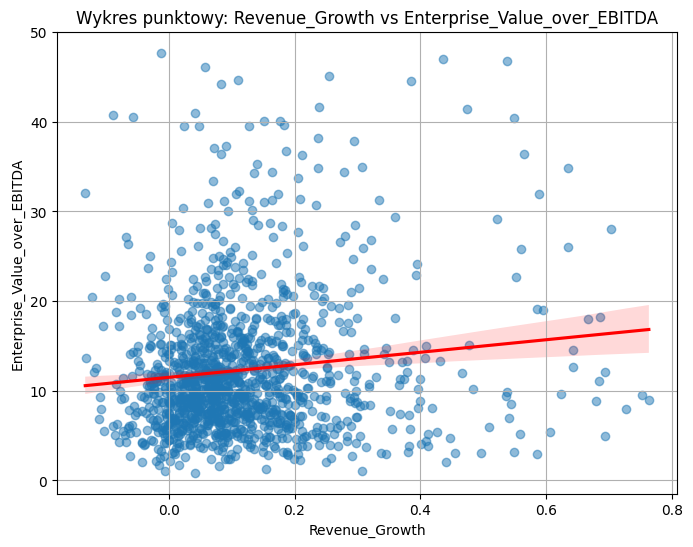

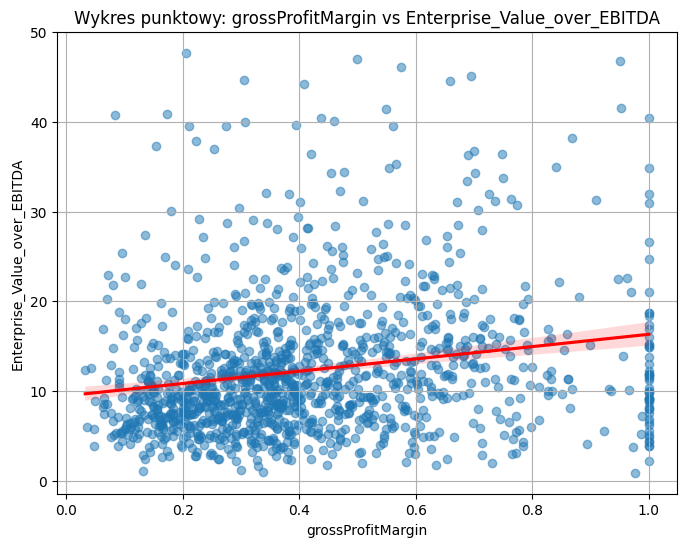

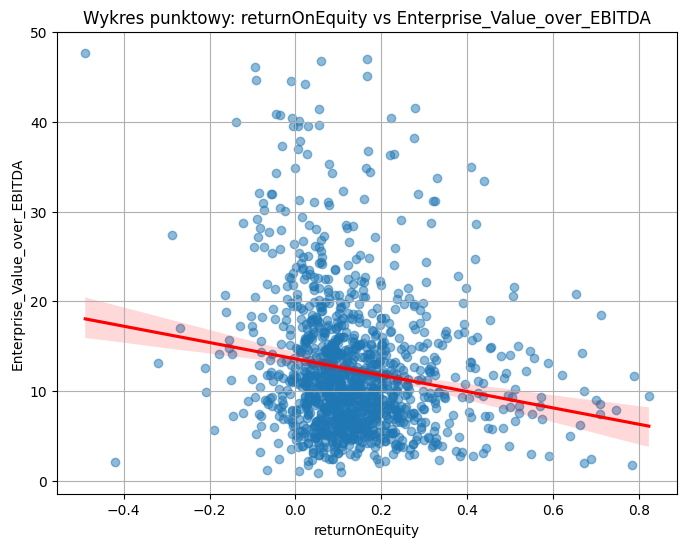

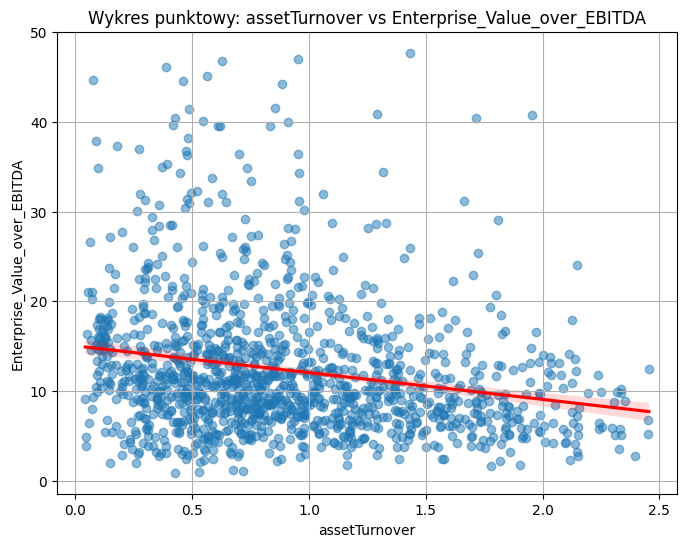

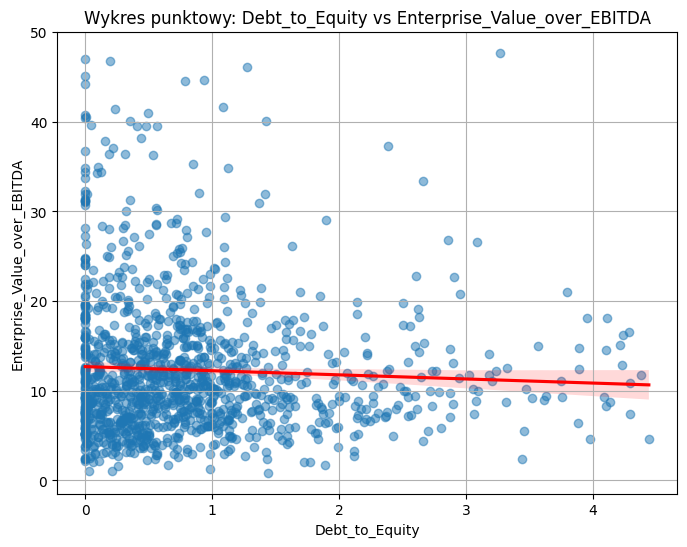

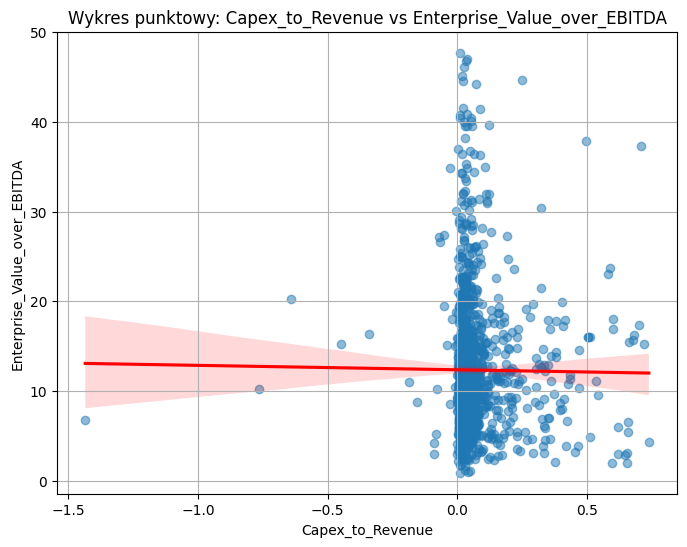

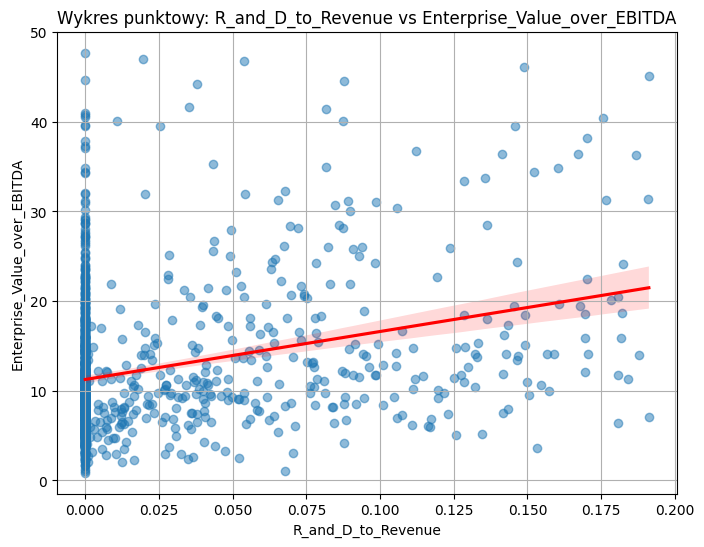

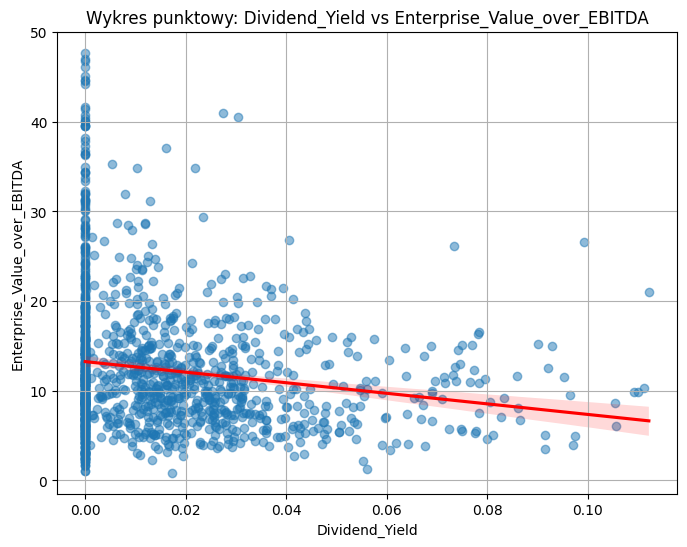

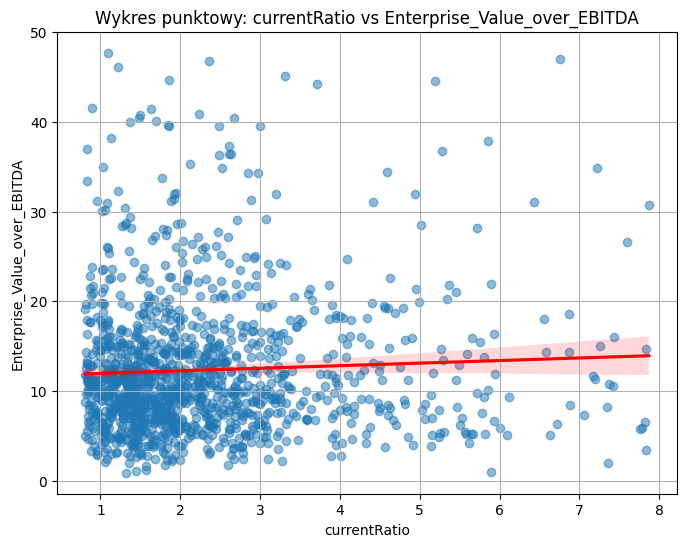

In [ ]:
for var in variables:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=df[var], y=y, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    plt.title(f'Scatter Plot: {var} vs Enterprise_Value_over_EBITDA')
    plt.xlabel(var)
    plt.ylabel('Enterprise_Value_over_EBITDA')
    plt.grid(True)
    plt.show()

In [79]:
formula2 = """
Enterprise_Value_over_EBITDA ~ 
    Revenue_Growth+ grossProfitMargin + returnOnEquity + assetTurnover  + Debt_to_Equity + Debt_to_Equity_squared +
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + returnOnEquityXpositiveROE
"""

In [80]:
m2 = smf.ols(formula=formula2, data=df).fit()
print(m2.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.188
Model:                                      OLS   Adj. R-squared:                  0.182
Method:                           Least Squares   F-statistic:                     29.32
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):           4.74e-51
Time:                                  00:30:49   Log-Likelihood:                -4265.3
No. Observations:                          1276   AIC:                             8553.
Df Residuals:                              1265   BIC:                             8609.
Df Model:                                    10                                         
Covariance Type:                      nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

In [81]:
df['residuals'] = m2.resid ** 2

In [82]:
formula_residuals = """
residuals ~ Revenue_Growth+ grossProfitMargin + returnOnEquity + assetTurnover + Debt_to_Equity + Debt_to_Equity_squared +
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + returnOnEquityXpositiveROE
"""
model_residuals = smf.ols(formula=formula_residuals, data= df).fit()
print(model_residuals.summary())

                            OLS Regression Results                            
Dep. Variable:              residuals   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     15.05
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.21e-25
Time:                        00:30:49   Log-Likelihood:                -7666.9
No. Observations:                1276   AIC:                         1.536e+04
Df Residuals:                    1265   BIC:                         1.541e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

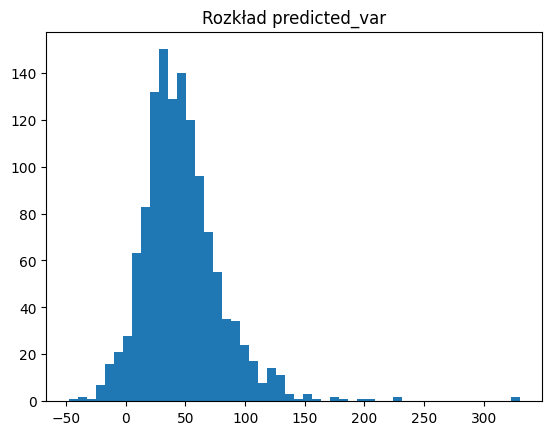

Min: -47.94249050358625
Max: 330.04395967627704


In [ ]:
predicted_var = model_residuals.predict()
weights_fgls = 1 / (predicted_var + 1e-6)
import matplotlib.pyplot as plt

plt.hist(predicted_var, bins=50)
plt.title("Distribution of predicted_var")
plt.show()

print("Min:", predicted_var.min())
print("Max:", predicted_var.max())

In [84]:
import numpy as np

predicted_var_clean = np.maximum(predicted_var, 1.0)

weights_fgls = 1 / predicted_var_clean

model_fgls1 = smf.wls(formula=formula2, data=df, weights=weights_fgls).fit()
print(model_fgls1.summary())

                                 WLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.220
Model:                                      WLS   Adj. R-squared:                  0.213
Method:                           Least Squares   F-statistic:                     35.58
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):           1.31e-61
Time:                                  00:30:49   Log-Likelihood:                -4275.6
No. Observations:                          1276   AIC:                             8573.
Df Residuals:                              1265   BIC:                             8630.
Df Model:                                    10                                         
Covariance Type:                      nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------

## Variance Reweighting: Net Effect

Purpose: correct cross-sectional error-variance heterogeneity and test whether fit improves.

Result: moving from OLS to WLS/FGLS-like estimation improves fit from about $R^2=0.188$ to $R^2=0.220$ (non-sector specification).

Meaning: heteroskedasticity is economically and statistically material; once variance structure is accounted for, the model tracks EV/EBITDA dispersion better. Interpretation should therefore prioritize robust/weighted results rather than classical OLS alone.

# Sector-Augmented Econometric Models

Purpose: test whether controlling for sector membership improves EV/EBITDA explanation and preserves the stability of financial-variable effects.

This is a key pre-final step because it separates within-sector financial effects from sector-level valuation premia/discounts.

In [85]:
df.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,Dividend_Yield,currentRatio_squared,currentRatio,Sector,positiveROE,returnOnEquityXpositiveROE,residuals
0,7.0919,0.1289,0.297,0.617336,0.2824,1.446586,0.553660,0.3535,0.124962,0.2143,0.1912,0.0256,2.996361,1.731,Technology,1,0.2824,121.548868
1,3.0421,0.4955,0.465,0.588694,0.4377,1.283837,0.700641,0.1436,0.020621,0.2922,0.0704,0.0000,7.767369,2.787,Technology,1,0.4377,146.341963
2,13.6724,0.1586,0.224,0.383437,0.5556,6.430249,0.726215,1.0685,1.141692,0.0501,0.0536,0.0120,1.283689,1.133,Technology,1,0.5556,6.180862
3,15.3298,0.1428,0.150,0.652474,0.2003,3.053173,0.426351,0.9890,0.978121,0.1054,0.1334,0.0165,8.415801,2.901,Technology,1,0.2003,4.810520
4,10.8702,0.0227,0.023,0.091095,0.1023,4.431920,0.625002,4.2918,18.419547,0.0486,0.0000,0.0784,1.440000,1.200,Consumer Cyclical,1,0.1023,3.167662


In [86]:
model_columns_sectors = ['Enterprise_Value_over_EBITDA',
                    'Revenue_Growth',
                    'Profit_Margin', 'grossProfitMargin', 
                    'returnOnEquity',
                    'assetTurnover', 'Debt_to_Equity',
                    'Debt_to_Equity_squared',
                    'Capex_to_Revenue', 'R_and_D_to_Revenue', 
                    'Dividend_Yield', 'currentRatio', 'currentRatio_squared', 'returnOnEquityXpositiveROE', 'Sector'
                    ]

df_sectors = df[model_columns_sectors]
df_sectors.head()
sector_cols = [col for col in df_sectors.columns if col.startswith('Sector_')]
df_sectors.columns = df_sectors.columns.str.replace(' ', '_')
df_sectors = pd.get_dummies(df_sectors, columns=['Sector'], drop_first=True)
len(df_sectors)


1276

In [ ]:
original_sectors = df['Sector']

sorted_sectors = sorted(original_sectors.dropna().unique())

base_sector = sorted_sectors[0]

print(f"Base sector: {base_sector}")

Sektor bazowy to: Basic Materials


In [88]:
print(df_sectors.columns)
df_sectors.head()

Index(['Enterprise_Value_over_EBITDA', 'Revenue_Growth', 'Profit_Margin',
       'grossProfitMargin', 'returnOnEquity', 'assetTurnover',
       'Debt_to_Equity', 'Debt_to_Equity_squared', 'Capex_to_Revenue',
       'R_and_D_to_Revenue', 'Dividend_Yield', 'currentRatio',
       'currentRatio_squared', 'returnOnEquityXpositiveROE',
       'Sector_Communication Services', 'Sector_Consumer Cyclical',
       'Sector_Consumer Defensive', 'Sector_Energy',
       'Sector_Financial Services', 'Sector_Healthcare', 'Sector_Industrials',
       'Sector_Real Estate', 'Sector_Technology', 'Sector_Utilities'],
      dtype='object')


,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,...,Sector_Communication Services,Sector_Consumer Cyclical,Sector_Consumer Defensive,Sector_Energy,Sector_Financial Services,Sector_Healthcare,Sector_Industrials,Sector_Real Estate,Sector_Technology,Sector_Utilities
0,7.0919,0.1289,0.297,0.617336,0.2824,0.553660,0.3535,0.124962,0.2143,0.1912,...,False,False,False,False,False,False,False,False,True,False
1,3.0421,0.4955,0.465,0.588694,0.4377,0.700641,0.1436,0.020621,0.2922,0.0704,...,False,False,False,False,False,False,False,False,True,False
2,13.6724,0.1586,0.224,0.383437,0.5556,0.726215,1.0685,1.141692,0.0501,0.0536,...,False,False,False,False,False,False,False,False,True,False
3,15.3298,0.1428,0.150,0.652474,0.2003,0.426351,0.9890,0.978121,0.1054,0.1334,...,False,False,False,False,False,False,False,False,True,False
4,10.8702,0.0227,0.023,0.091095,0.1023,0.625002,4.2918,18.419547,0.0486,0.0000,...,False,True,False,False,False,False,False,False,False,False


In [89]:
df_sectors.columns = df_sectors.columns.str.replace(' ', '_')
sector_cols = [col for col in df_sectors.columns if col.startswith('Sector_')]
df_sectors.columns = df_sectors.columns.str.replace(' ', '_')
df_sectors.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,...,Sector_Communication_Services,Sector_Consumer_Cyclical,Sector_Consumer_Defensive,Sector_Energy,Sector_Financial_Services,Sector_Healthcare,Sector_Industrials,Sector_Real_Estate,Sector_Technology,Sector_Utilities
0,7.0919,0.1289,0.297,0.617336,0.2824,0.553660,0.3535,0.124962,0.2143,0.1912,...,False,False,False,False,False,False,False,False,True,False
1,3.0421,0.4955,0.465,0.588694,0.4377,0.700641,0.1436,0.020621,0.2922,0.0704,...,False,False,False,False,False,False,False,False,True,False
2,13.6724,0.1586,0.224,0.383437,0.5556,0.726215,1.0685,1.141692,0.0501,0.0536,...,False,False,False,False,False,False,False,False,True,False
3,15.3298,0.1428,0.150,0.652474,0.2003,0.426351,0.9890,0.978121,0.1054,0.1334,...,False,False,False,False,False,False,False,False,True,False
4,10.8702,0.0227,0.023,0.091095,0.1023,0.625002,4.2918,18.419547,0.0486,0.0000,...,False,True,False,False,False,False,False,False,False,False


In [90]:
df_sectors.columns = df_sectors.columns.str.replace(' ', '_')

formula_sectors  = """
Enterprise_Value_over_EBITDA ~ 
    Revenue_Growth + grossProfitMargin + returnOnEquity + 
    assetTurnover + Debt_to_Equity + Debt_to_Equity_squared +
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + 
    currentRatio + currentRatio_squared + returnOnEquityXpositiveROE
"""



for sector in sector_cols:
    formula_sectors += ' + ' + sector  



print(formula_sectors)



Enterprise_Value_over_EBITDA ~ 
    Revenue_Growth + grossProfitMargin + returnOnEquity + 
    assetTurnover + Debt_to_Equity + Debt_to_Equity_squared +
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + 
    currentRatio + currentRatio_squared + returnOnEquityXpositiveROE
 + Sector_Communication_Services + Sector_Consumer_Cyclical + Sector_Consumer_Defensive + Sector_Energy + Sector_Financial_Services + Sector_Healthcare + Sector_Industrials + Sector_Real_Estate + Sector_Technology + Sector_Utilities


In [91]:
df.head()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,fixedAssetTurnover,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,Dividend_Yield,currentRatio_squared,currentRatio,Sector,positiveROE,returnOnEquityXpositiveROE,residuals
0,7.0919,0.1289,0.297,0.617336,0.2824,1.446586,0.553660,0.3535,0.124962,0.2143,0.1912,0.0256,2.996361,1.731,Technology,1,0.2824,121.548868
1,3.0421,0.4955,0.465,0.588694,0.4377,1.283837,0.700641,0.1436,0.020621,0.2922,0.0704,0.0000,7.767369,2.787,Technology,1,0.4377,146.341963
2,13.6724,0.1586,0.224,0.383437,0.5556,6.430249,0.726215,1.0685,1.141692,0.0501,0.0536,0.0120,1.283689,1.133,Technology,1,0.5556,6.180862
3,15.3298,0.1428,0.150,0.652474,0.2003,3.053173,0.426351,0.9890,0.978121,0.1054,0.1334,0.0165,8.415801,2.901,Technology,1,0.2003,4.810520
4,10.8702,0.0227,0.023,0.091095,0.1023,4.431920,0.625002,4.2918,18.419547,0.0486,0.0000,0.0784,1.440000,1.200,Consumer Cyclical,1,0.1023,3.167662


In [92]:
df_sectors2 = df_sectors.copy()

In [93]:
df_14col = df[[
    'Enterprise_Value_over_EBITDA',
    'Revenue_Growth',
    'Profit_Margin',
    'grossProfitMargin',
    'returnOnEquity',
    'assetTurnover',
    'Debt_to_Equity',
    'Debt_to_Equity_squared',
    'Capex_to_Revenue',
    'R_and_D_to_Revenue',
    'Dividend_Yield',
    'currentRatio',
    'currentRatio_squared',
    'returnOnEquityXpositiveROE',
    'Sector'
]]


In [ ]:
model_sectors = smf.ols(formula=formula_sectors, data=df_sectors).fit()
print(model_sectors.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.252
Model:                                      OLS   Adj. R-squared:                  0.239
Method:                           Least Squares   F-statistic:                     19.22
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):           2.27e-64
Time:                                  00:32:53   Log-Likelihood:                -4212.7
No. Observations:                          1276   AIC:                             8471.
Df Residuals:                              1253   BIC:                             8590.
Df Model:                                    22                                         
Covariance Type:                      nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np

influence = model_sectors.get_influence()
cooks_d = influence.cooks_distance[0]

n = df_sectors.shape[0]
threshold = 4 / n

mask = cooks_d < threshold
df_sectors_cook2 = df_sectors.loc[mask]
print(threshold)
print(f"Removed {np.sum(~mask)} observations ({round(100 * np.sum(~mask)/n, 2)}%)")

0.003134796238244514
Usunięto 81 obserwacji (6.35%)


1276

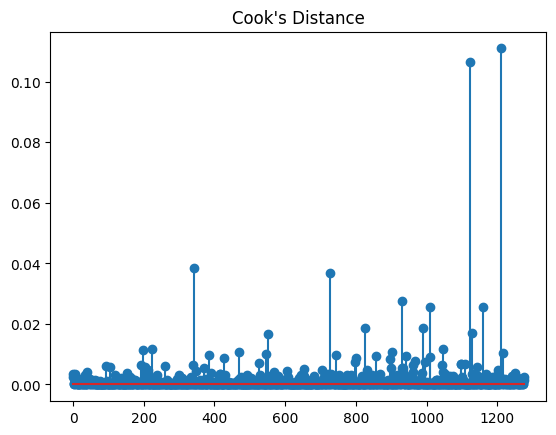

In [97]:
plt.stem(cooks_d)
plt.title("Cook's Distance")
len(df_sectors)

In [ ]:
model_sectors_cook2 = smf.ols(formula=formula_sectors, data=df_sectors_cook2).fit()
print(model_sectors_cook2.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.297
Model:                                      OLS   Adj. R-squared:                  0.284
Method:                           Least Squares   F-statistic:                     22.54
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):           1.28e-74
Time:                                  01:20:30   Log-Likelihood:                -3569.1
No. Observations:                          1195   AIC:                             7184.
Df Residuals:                              1172   BIC:                             7301.
Df Model:                                    22                                         
Covariance Type:                      nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----

In [ ]:
f_test_result = model_sectors_cook2.f_test(hypotheses)
print(f_test_result)
f_test_result = model_sectors_cook2.f_test(hypotheses2)
print(f_test_result)

<F test: F=3.372907024199077, p=0.03462299581299693, df_denom=1.17e+03, df_num=2>
<F test: F=3.5976010534950236, p=0.02769224810084909, df_denom=1.17e+03, df_num=2>


In [ ]:
sector_vars = [
    'Sector_Communication_Services[T.True]',
    'Sector_Consumer_Cyclical[T.True]',
    'Sector_Consumer_Defensive[T.True]',
    'Sector_Energy[T.True]',
    'Sector_Financial_Services[T.True]',
    'Sector_Healthcare[T.True]',
    'Sector_Industrials[T.True]',
    'Sector_Real_Estate[T.True]',
    'Sector_Technology[T.True]',
    'Sector_Utilities[T.True]'
]

f_test_result = model_sectors_cook2.f_test(" = ".join([f"{var} = 0" for var in sector_vars]))

print(f_test_result)

<F test: F=np.float64(20.710967718277352), p=1.0203857477735873e-35, df_denom=1.17e+03, df_num=10>


c:\Users\tymot\.conda\envs\ratiosmodeling\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 10
  warnings.warn('covariance of constraints does not have full '


In [ ]:
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, linear_reset
from scipy.stats import jarque_bera
import pandas as pd

bp_test = het_breuschpagan(model_sectors_cook2.resid, model_sectors_cook2.model.exog)
white_test = het_white(model_sectors_cook2.resid, model_sectors_cook2.model.exog)
jb_stat, jb_pvalue = jarque_bera(model_sectors_cook2.resid)
reset_test = linear_reset(model_sectors_cook2, power=2, use_f=True)

print("Diagnostics for cross-sectional data (without time-series autocorrelation tests):")
print(f"Breusch-Pagan test: Stat = {bp_test[2]:.3f}, p-value = {bp_test[3]:.2e}")
print(f"White test: Stat = {white_test[2]:.3f}, p-value = {white_test[3]:.2e}")
print(f"Jarque-Bera test: Stat = {jb_stat:.3f}, p-value = {jb_pvalue:.2e}")
print(f"RESET test: F = {reset_test.fvalue:.3f}, p-value = {reset_test.pvalue:.2e}")

robust_hc3 = model_sectors_cook2.get_robustcov_results(cov_type='HC3')
comparison = pd.DataFrame(index=model_sectors_cook2.params.index)
comparison['coef_ols'] = model_sectors_cook2.params
comparison['se_ols'] = model_sectors_cook2.bse
comparison['p_ols'] = model_sectors_cook2.pvalues
comparison['se_hc3'] = robust_hc3.bse
comparison['p_hc3'] = robust_hc3.pvalues

print("\nTOP 12 variables by HC3 p-value:")
print(comparison.sort_values('p_hc3').head(12))

Diagnostyka dla danych przekrojowych (bez testow autokorelacji czasowej):
Breusch-Pagan test: Stat = 4.367, p-value = 1.00e-10
White test: Stat = 1.245, p-value = 1.72e-02
Jarque-Bera test: Stat = 143.881, p-value = 5.71e-32
RESET test: F = 20.781, p-value = 5.69e-06

TOP 12 zmiennych wg p-value HC3:
                                    coef_ols    se_ols         p_ols  \
Intercept                          10.559478  1.042433  3.555287e-23   
Sector_Healthcare[T.True]           5.268668  0.741442  2.070102e-12   
Sector_Real_Estate[T.True]          4.868950  0.848336  1.208844e-08   
Sector_Consumer_Defensive[T.True]   4.420114  0.756885  6.758736e-09   
returnOnEquity                    -39.094545  6.513231  2.589857e-09   
assetTurnover                      -1.956039  0.354381  4.180498e-08   
returnOnEquityXpositiveROE         37.184497  6.948347  1.048214e-07   
Dividend_Yield                    -32.118142  7.811359  4.201017e-05   
Revenue_Growth                      6.258377  1.22

## Diagnostics: Empirical Verdict

Purpose: verify whether classical OLS assumptions are sufficient for credible inference.

Result:
- Breusch-Pagan: $p=1.00\times 10^{-10}$,
- White: $p=1.72\times 10^{-2}$,
- Jarque-Bera: $p=5.71\times 10^{-32}$,
- RESET: $p=5.69\times 10^{-6}$.

Meaning:
- error variance is not constant -> robust SE / weighting is required,
- residuals are non-normal -> stronger reliance on robust inference is warranted,
- RESET indicates functional-form tension -> supports retaining non-linear and structurally richer specifications (including sector controls).

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import f

def chow_test_two_groups(formula, full_data, group_a, group_b):
    model_a = smf.ols(formula, data=group_a).fit()
    model_b = smf.ols(formula, data=group_b).fit()
    model_full = smf.ols(formula, data=full_data).fit()

    n_a = model_a.nobs
    n_b = model_b.nobs
    k = int(model_full.df_model + 1)

    rss_a = np.sum(model_a.resid ** 2)
    rss_b = np.sum(model_b.resid ** 2)
    rss_full = np.sum(model_full.resid ** 2)

    df_num = k
    df_den = int(n_a + n_b - 2 * k)
    if df_den <= 0:
        raise ValueError("Too few observations relative to the number of model parameters.")

    numerator = (rss_full - (rss_a + rss_b)) / df_num
    denominator = (rss_a + rss_b) / df_den
    f_stat = numerator / denominator
    p_value = 1 - f.cdf(f_stat, df_num, df_den)

    return f_stat, p_value, df_num, df_den

# Reconstruct sector labels from one-hot encoded columns.
sector_dummy_cols = [c for c in df_sectors_cook2.columns if c.startswith('Sector_')]
sector_labels = pd.Series('Sector_Base', index=df_sectors_cook2.index)

if sector_dummy_cols:
    sector_matrix = df_sectors_cook2[sector_dummy_cols].astype(int)
    has_dummy = sector_matrix.sum(axis=1) > 0
    sector_labels.loc[has_dummy] = sector_matrix.loc[has_dummy].idxmax(axis=1)

sector_counts = sector_labels.value_counts()
top_sectors = sector_counts.head(2).index.tolist()

print("Largest sector groups for the test:")
print(sector_counts.head(5))

Najwieksze grupy sektorowe do testu:
Sector_Industrials          274
Sector_Consumer_Cyclical    233
Sector_Technology           192
Sector_Base                 112
Sector_Healthcare            86
Name: count, dtype: int64


In [ ]:
print("Structural stability tests (cross-sectional data):")

if len(top_sectors) >= 2:
    group_sector_1 = df_sectors_cook2[sector_labels == top_sectors[0]]
    group_sector_2 = df_sectors_cook2[sector_labels == top_sectors[1]]

    print(
        f"\n1) Sectors: {top_sectors[0]} (n={len(group_sector_1)}) vs "
        f"{top_sectors[1]} (n={len(group_sector_2)})"
    )
    try:
        f_sector, p_sector, df1_sector, df2_sector = chow_test_two_groups(
            formula_sectors,
            pd.concat([group_sector_1, group_sector_2]),
            group_sector_1,
            group_sector_2,
        )
        print(f"   Chow F = {f_sector:.4f}, p-value = {p_sector:.4g}, df=({df1_sector}, {df2_sector})")
    except Exception as err:
        print(f"   Could not compute the sector test: {err}")
else:
    print("\n1) Sectors: insufficient number of groups.")

debt_median = df_sectors_cook2['Debt_to_Equity'].median()
group_low_debt = df_sectors_cook2[df_sectors_cook2['Debt_to_Equity'] <= debt_median]
group_high_debt = df_sectors_cook2[df_sectors_cook2['Debt_to_Equity'] > debt_median]

print(
    f"\n2) Debt: low<=median (n={len(group_low_debt)}) vs "
    f"high>median (n={len(group_high_debt)})"
)

try:
    f_debt, p_debt, df1_debt, df2_debt = chow_test_two_groups(
        formula_sectors,
        pd.concat([group_low_debt, group_high_debt]),
        group_low_debt,
        group_high_debt,
    )
    print(f"   Chow F = {f_debt:.4f}, p-value = {p_debt:.4g}, df=({df1_debt}, {df2_debt})")
    if p_debt < 0.05:
        print("   Conclusion: model structure differs significantly between debt groups.")
    else:
        print("   Conclusion: no strong evidence of different structure between debt groups.")
except Exception as err:
    print(f"   Could not compute the debt-group test: {err}")

Testy stabilnosci strukturalnej (dane przekrojowe):

1) Sektory: Sector_Industrials (n=274) vs Sector_Consumer_Cyclical (n=233)
   Chow F = 2.0072, p-value = 0.01585, df=(14, 479)

2) Zadluzenie: low<=median (n=598) vs high>median (n=597)
   Chow F = 1.2576, p-value = 0.1862, df=(23, 1149)
   Wniosek: brak silnych dowodow na rozna strukture miedzy grupami zadluzenia.


In [ ]:
bp_test = sms.het_breuschpagan(model_sectors_cook2.resid, model_sectors_cook2.model.exog)
print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 2.774466886958465e-10


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = model_sectors_cook2.model.exog
vif_df = pd.DataFrame()
vif_df["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_df["variable"] = model_sectors_cook2.model.exog_names
print(vif_df)

          VIF                               variable
0   55.369210                              Intercept
1    1.134735  Sector_Communication_Services[T.True]
2    2.760059       Sector_Consumer_Cyclical[T.True]
3    1.674218      Sector_Consumer_Defensive[T.True]
4    1.817067                  Sector_Energy[T.True]
5    1.912176      Sector_Financial_Services[T.True]
6    1.870770              Sector_Healthcare[T.True]
7    2.833806             Sector_Industrials[T.True]
8    2.157005             Sector_Real_Estate[T.True]
9    2.930768              Sector_Technology[T.True]
10   1.229927               Sector_Utilities[T.True]
11   1.167500                         Revenue_Growth
12   1.866531                      grossProfitMargin
13  39.814706                         returnOnEquity
14   1.882215                          assetTurnover
15   8.487236                         Debt_to_Equity
16   7.529455                 Debt_to_Equity_squared
17   1.555962                       Capex_to_R

In [106]:
print(df_sectors_cook2[['returnOnEquity', 'returnOnEquityXpositiveROE']].corr())
print(df_sectors_cook2[['Debt_to_Equity', 'Debt_to_Equity_squared']].corr())

                            returnOnEquity  returnOnEquityXpositiveROE
returnOnEquity                    1.000000                    0.986587
returnOnEquityXpositiveROE        0.986587                    1.000000
                        Debt_to_Equity  Debt_to_Equity_squared
Debt_to_Equity                1.000000                0.922091
Debt_to_Equity_squared        0.922091                1.000000


In [ ]:
from statsmodels.stats.diagnostic import linear_reset

X = model_sectors_cook2.model.exog
y = model_sectors_cook2.model.endog

model_np = sm.OLS(y, X).fit()
reset = linear_reset(model_np, power=2, test_type='fitted', use_f=True)
print(reset)

<F test: F=20.78144082470936, p=5.688028622900315e-06, df_denom=1.17e+03, df_num=1>


In [108]:
df_sectors.head()
df_sectors.describe()

,Enterprise_Value_over_EBITDA,Revenue_Growth,Profit_Margin,grossProfitMargin,returnOnEquity,assetTurnover,Debt_to_Equity,Debt_to_Equity_squared,Capex_to_Revenue,R_and_D_to_Revenue,Dividend_Yield,currentRatio,currentRatio_squared,returnOnEquityXpositiveROE
count,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000,1276.000000
mean,12.326177,0.117927,0.090638,0.418011,0.137103,0.904659,0.811507,1.366512,0.068813,0.019866,0.015796,2.288411,7.008869,0.144219
std,7.601877,0.131578,0.192334,0.226630,0.142767,0.541097,0.841738,2.820600,0.124773,0.041190,0.020835,1.331703,9.472144,0.131504
min,0.879500,-0.132500,-0.561000,0.032281,-0.489300,0.041906,0.000000,0.000000,-1.434300,0.000000,0.000000,0.810000,0.656100,-0.000000
25%,7.331725,0.036600,0.029000,0.250585,0.054700,0.486263,0.206275,0.042549,0.018800,0.000000,0.000000,1.373570,1.886696,0.054700
50%,10.613250,0.088450,0.064000,0.369266,0.114600,0.797437,0.581650,0.338318,0.034800,0.000000,0.009300,1.896500,3.596712,0.114600
75%,15.087225,0.169825,0.117000,0.549022,0.194725,1.255165,1.092525,1.193611,0.068950,0.014150,0.024750,2.764000,7.639696,0.194725
max,47.722600,0.762800,5.652000,1.000000,0.822600,2.455339,4.438900,19.703833,0.737600,0.191200,0.112200,7.870000,61.936900,0.822600


In [109]:
formula_residuals_sectors = """
residuals ~
    Revenue_Growth + grossProfitMargin + returnOnEquity + 
    assetTurnover + Debt_to_Equity + Debt_to_Equity_squared +
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + 
    currentRatio + currentRatio_squared + returnOnEquityXpositiveROE
 + Sector_Communication_Services + Sector_Consumer_Cyclical + Sector_Consumer_Defensive + 
 Sector_Energy + Sector_Financial_Services + Sector_Healthcare + Sector_Industrials + 
 Sector_Real_Estate + Sector_Technology + Sector_Utilities
"""
print(formula_residuals_sectors)


residuals ~
    Revenue_Growth + grossProfitMargin + returnOnEquity + 
    assetTurnover + Debt_to_Equity + Debt_to_Equity_squared +
    Capex_to_Revenue + R_and_D_to_Revenue + Dividend_Yield + 
    currentRatio + currentRatio_squared + returnOnEquityXpositiveROE
 + Sector_Communication_Services + Sector_Consumer_Cyclical + Sector_Consumer_Defensive + 
 Sector_Energy + Sector_Financial_Services + Sector_Healthcare + Sector_Industrials + 
 Sector_Real_Estate + Sector_Technology + Sector_Utilities



In [ ]:
df_sectors_cook2 = df_sectors_cook2.copy()
df_sectors_cook2["residuals"] = model_sectors_cook2.resid ** 2

model_residuals_sectors = smf.ols(formula=formula_residuals_sectors, data=df_sectors_cook2).fit()
print(model_residuals_sectors.summary())

                            OLS Regression Results                            
Dep. Variable:              residuals   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     4.367
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.00e-10
Time:                        01:20:33   Log-Likelihood:                -6042.8
No. Observations:                1195   AIC:                         1.213e+04
Df Residuals:                    1172   BIC:                         1.225e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

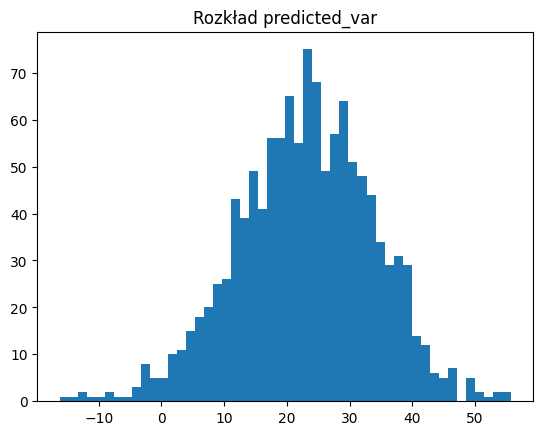

Min: -16.193333956083954
Max: 55.68926935598161


In [ ]:
predicted_var = model_residuals_sectors.predict()
weights_fgls = 1 / (predicted_var + 1e-6)
import matplotlib.pyplot as plt

plt.hist(predicted_var, bins=50)
plt.title("Distribution of predicted_var")
plt.show()

print("Min:", predicted_var.min())
print("Max:", predicted_var.max())

In [112]:
predicted_var_clean = np.maximum(predicted_var, 1.0)

weights_fgls = 1 / predicted_var_clean

model_fgls_sectors = smf.wls(formula=formula_sectors, data=df_sectors_cook2, weights=weights_fgls).fit()
print(model_fgls_sectors.summary())

                                 WLS Regression Results                                 
Dep. Variable:     Enterprise_Value_over_EBITDA   R-squared:                       0.369
Model:                                      WLS   Adj. R-squared:                  0.358
Method:                           Least Squares   F-statistic:                     31.21
Date:                          Wed, 18 Mar 2026   Prob (F-statistic):          3.06e-101
Time:                                  01:20:34   Log-Likelihood:                -3530.7
No. Observations:                          1195   AIC:                             7107.
Df Residuals:                              1172   BIC:                             7224.
Df Model:                                    22                                         
Covariance Type:                      nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----

In [119]:
sector_vars = [
    'Sector_Communication_Services[T.True]',
    'Sector_Consumer_Cyclical[T.True]',
    'Sector_Consumer_Defensive[T.True]',
    'Sector_Energy[T.True]',
    'Sector_Financial_Services[T.True]',
    'Sector_Healthcare[T.True]',
    'Sector_Industrials[T.True]',
    'Sector_Real_Estate[T.True]',
    'Sector_Technology[T.True]',
    'Sector_Utilities[T.True]'
]

f_test_result_fgls = model_fgls_sectors.f_test(" = ".join([f"{var} = 0" for var in sector_vars]))

print(f_test_result_fgls)

<F test: F=np.float64(20.730351492479116), p=9.426743318755023e-36, df_denom=1.17e+03, df_num=10>


c:\Users\tymot\.conda\envs\ratiosmodeling\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 10
  warnings.warn('covariance of constraints does not have full '


## Sector and Stability Block: Main Findings

Purpose: test whether the model requires sector effects and whether structural relations are stable across groups.

Result (key figures):
- sector OLS: $R^2=0.252$, after influential-point filtering: $R^2=0.297$,
- sector WLS/FGLS-like: $R^2=0.369$ (adj. $R^2=0.358$),
- joint significance of sector dummies: $p\approx 1.02\times 10^{-35}$ (very strong effect),
- sector-vs-sector Chow test: $p=0.0159$ (structural differences across major sectors),
- low-vs-high debt Chow test: $p=0.1862$ (no strong structural split under that partition),
- in sector models, non-linear blocks are significant (for example $p=0.0346$ and $p=0.0277$; in WLS also significant: $p=1.56\times 10^{-5}$ and $p=0.0179$).

Meaning: sector membership is a major carrier of valuation heterogeneity, and once sector structure is modeled, leverage/liquidity non-linearities become empirically clear. The strongest and most decision-useful final specification is the sector-augmented model with variance correction.

In [120]:
print(model_fgls_sectors.params.index)
hypotheses_full = """
Revenue_Growth = 0,
grossProfitMargin = 0,
returnOnEquity = 0,
returnOnEquityXpositiveROE = 0,
assetTurnover = 0,
Debt_to_Equity = 0,
Debt_to_Equity_squared = 0,
Capex_to_Revenue = 0,
R_and_D_to_Revenue = 0,
Dividend_Yield = 0,
currentRatio = 0,
currentRatio_squared = 0
"""



Index(['Intercept', 'Sector_Communication_Services[T.True]',
       'Sector_Consumer_Cyclical[T.True]', 'Sector_Consumer_Defensive[T.True]',
       'Sector_Energy[T.True]', 'Sector_Financial_Services[T.True]',
       'Sector_Healthcare[T.True]', 'Sector_Industrials[T.True]',
       'Sector_Real_Estate[T.True]', 'Sector_Technology[T.True]',
       'Sector_Utilities[T.True]', 'Revenue_Growth', 'grossProfitMargin',
       'returnOnEquity', 'assetTurnover', 'Debt_to_Equity',
       'Debt_to_Equity_squared', 'Capex_to_Revenue', 'R_and_D_to_Revenue',
       'Dividend_Yield', 'currentRatio', 'currentRatio_squared',
       'returnOnEquityXpositiveROE'],
      dtype='object')


In [121]:
print(type(hypotheses_full))
print(repr(hypotheses_full))


<class 'str'>
'\nRevenue_Growth = 0,\ngrossProfitMargin = 0,\nreturnOnEquity = 0,\nreturnOnEquityXpositiveROE = 0,\nassetTurnover = 0,\nDebt_to_Equity = 0,\nDebt_to_Equity_squared = 0,\nCapex_to_Revenue = 0,\nR_and_D_to_Revenue = 0,\nDividend_Yield = 0,\ncurrentRatio = 0,\ncurrentRatio_squared = 0\n'


In [127]:

wald_test_result = model_fgls_sectors.wald_test(hypotheses_full)

print(wald_test_result)
f_test_result_full = model_fgls_sectors.f_test(hypotheses_full)
print(f_test_result_full)

<F test: F=array([[23.74831389]]), p=7.102016719991428e-48, df_denom=1.17e+03, df_num=12>
<F test: F=23.748313888546033, p=7.102016719991428e-48, df_denom=1.17e+03, df_num=12>


In [128]:
f_test_result = model_fgls_sectors.f_test(hypotheses)
print(f_test_result)
f_test_result = model_fgls_sectors.f_test(hypotheses2)
print(f_test_result)

<F test: F=11.174485389690503, p=1.558382332321055e-05, df_denom=1.17e+03, df_num=2>
<F test: F=4.036649881346148, p=0.017902584194374644, df_denom=1.17e+03, df_num=2>


In [ ]:
financial_vars = [
    'Revenue_Growth',
    'grossProfitMargin',
    'returnOnEquity',
    'returnOnEquityXpositiveROE',
    'assetTurnover',
    'Debt_to_Equity',
    'Debt_to_Equity_squared',
    'Capex_to_Revenue',
    'R_and_D_to_Revenue',
    'Dividend_Yield',
    'currentRatio',
    'currentRatio_squared',
]

hypothesis = ' = 0, '.join(financial_vars) + ' = 0'

wald_test_result = model_fgls_sectors.wald_test(hypothesis)
print(wald_test_result)

<F test: F=array([[23.74831389]]), p=7.102016719991428e-48, df_denom=1.17e+03, df_num=12>


In [129]:
output_path = Path("../data/processed/df_sectors_cook2.csv")
df_sectors_cook2.to_csv(output_path, index=False)

print(f"Saved df_sectors_cook2 to: {output_path.resolve()}")
print(f"Shape: {df_sectors_cook2.shape}")

Saved df_sectors_cook2 to: C:\Users\tymot\OneDrive\Dokumenty\modeling_ev_ebitda_with_financial_ratios\data\processed\df_sectors_cook2.csv
Shape: (1195, 25)
